Using file: /data/projects/nckf/frekle/CMIP6_data/CESM2/thetao/masked/thetao_masked_r1i1p1f1.nc
Data shape: (165, 384, 320)
Reshaping to 2D for EOF: (165, 122880)
EOFs (flat) shape: (10, 122880)
PCs shape: (165, 10)


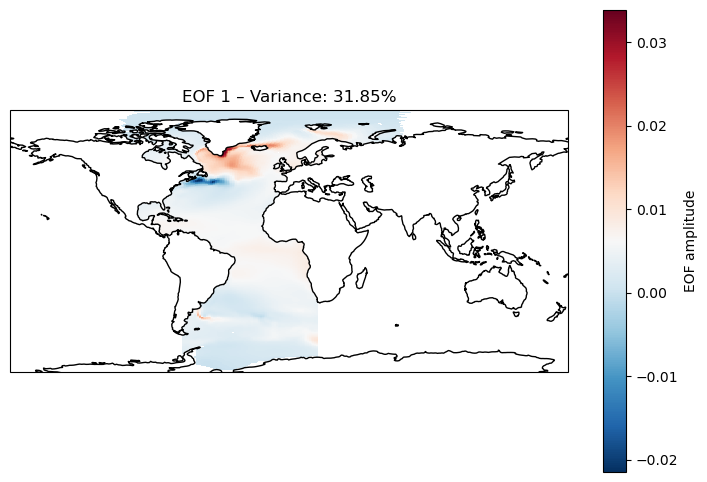

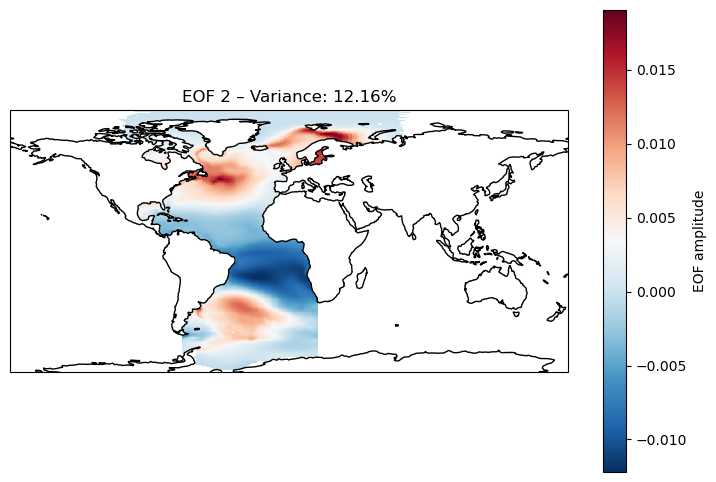

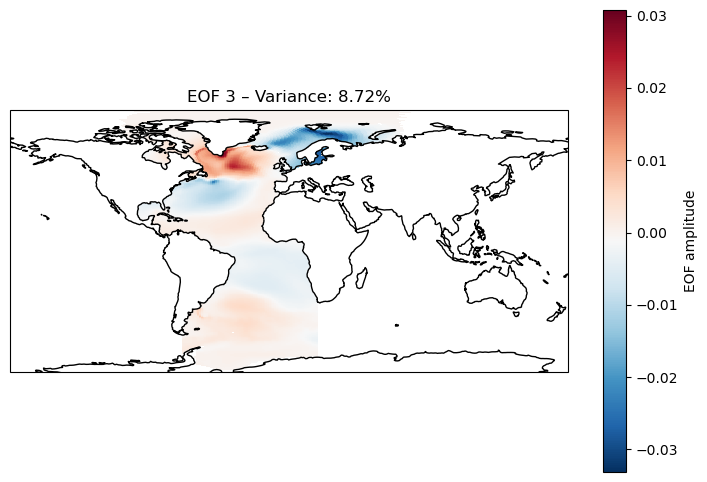

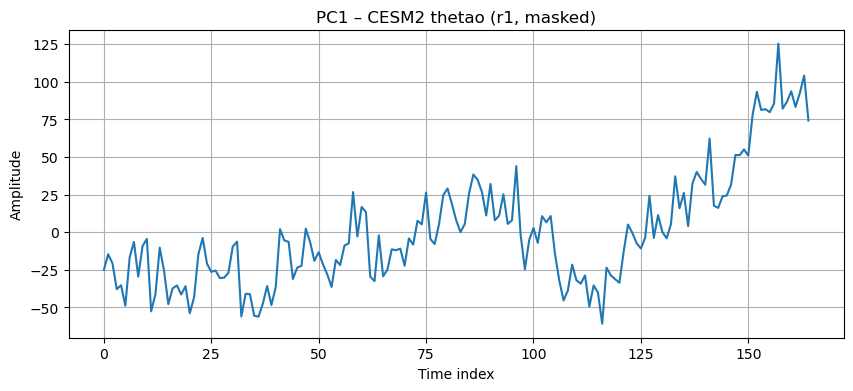

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from eofs.standard import Eof
import cartopy.crs as ccrs

# ----------------------------
# Paths and file selection
# ----------------------------
data_dir = "/data/projects/nckf/frekle/CMIP6_data/CESM2/thetao/masked/"

# pick ONE member to start with (e.g. r1)
files = sorted(glob(f"{data_dir}/thetao_masked_r1i1p1f1*.nc"))
if not files:
    raise FileNotFoundError("No file found for r1i1p1f1 in thetao_masked folder")

fname = files[0]
print("Using file:", fname)

ds = xr.open_dataset(fname)
da = ds["thetao"]   # (time, lev?, nlat, nlon)

# Surface only if lev exists
if "lev" in da.dims:
    da = da.isel(lev=0)

# keep coords for later
lat = ds["lat"]      # (nlat, nlon)
lon = ds["lon"]      # (nlat, nlon)

print("Data shape:", da.shape)   # (time, nlat, nlon)

# ----------------------------
# Prepare anomaly field
# ----------------------------
# remove time mean
da_anom = da - da.mean("time")

# convert to numpy
data = da_anom.values    # shape (time, nlat, nlon)
nt, ny, nx = data.shape
print("Reshaping to 2D for EOF:", (nt, ny * nx))

# reshape to (time, space)
data2d = data.reshape(nt, ny * nx)

# mask invalid (NaNs from land/other basins)
data2d_ma = np.ma.masked_invalid(data2d)

# ----------------------------
# EOF analysis with eofs.standard
# ----------------------------
solver = Eof(data2d_ma)

neofs = 10
eofs_flat = solver.eofs(neofs=neofs)            # (mode, space)
pcs = solver.pcs(npcs=neofs)                    # (time, mode)
variance = solver.varianceFraction()            # (mode,)

print("EOFs (flat) shape:", eofs_flat.shape)
print("PCs shape:", pcs.shape)

# reshape EOFs back to (mode, nlat, nlon)
eofs_3d = eofs_flat.reshape(neofs, ny, nx)

# wrap into xarray for nice plotting
eofs_da = xr.DataArray(
    eofs_3d,
    dims=("mode", "nlat", "nlon"),
    coords={
        "mode": np.arange(1, neofs + 1),
        "nlat": lat["nlat"] if "nlat" in lat.dims else np.arange(ny),
        "nlon": lon["nlon"] if "nlon" in lon.dims else np.arange(nx),
    },
    name="EOF"
)

# we’ll just reuse the lat/lon coordinate arrays for plotting
lat_vals = lat.values
lon_vals = lon.values

# ----------------------------
# Plot first 3 EOFs
# ----------------------------
for i in range(3):
    eof_map = eofs_3d[i, :, :]  # (nlat, nlon)

    plt.figure(figsize=(9, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()

    pc = plt.pcolormesh(
        lon_vals,
        lat_vals,
        eof_map,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        shading="nearest"
    )
    plt.colorbar(pc, label="EOF amplitude")
    plt.title(f"EOF {i+1} – Variance: {variance[i] * 100:.2f}%")
    plt.show()

# ----------------------------
# Plot PC1 time series
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(pcs[:, 0])
plt.grid(True)
plt.title("PC1 – CESM2 thetao (r1, masked)")
plt.xlabel("Time index")
plt.ylabel("Amplitude")
plt.show()


In [15]:
#!/usr/bin/env python3
# ============================================================
# CESM2 EOF analysis (loop over ALL masked thetao members)
# Using the EXACT method that worked for 1 member
# ============================================================

import os
import numpy as np
import xarray as xr
from glob import glob
from eofs.standard import Eof
import matplotlib.pyplot as plt

# ----------------------------
# Paths
# ----------------------------
data_dir = "/data/projects/nckf/frekle/CMIP6_data/CESM2/thetao/masked/"
outdir   = "/data/projects/nckf/frekle/EOF_results/CESM2/thetao/"
os.makedirs(outdir, exist_ok=True)

# -----------------------------------------------------------
# Loop over ALL masked thetao files
# -----------------------------------------------------------
files = sorted(glob(f"{data_dir}/thetao_masked_r*i1p1f1*.nc"))
print("Found files:", len(files))
for f in files:
    print(" →", os.path.basename(f))

# -----------------------------------------------------------
# Process each CESM2 member
# -----------------------------------------------------------
for f in files:
    fname = os.path.basename(f)
    member = fname.split("_")[-1].split(".")[0]   # r1i1p1f1 etc.

    print(f"\n🔄 Processing {member}")
    ds = xr.open_dataset(f)
    da = ds["thetao"]   # (time, nlat, nlon)

    # If lev exists, extract surface only
    if "lev" in da.dims:
        da = da.isel(lev=0)

    lat = ds["lat"]     # (nlat, nlon)
    lon = ds["lon"]

    # ----------------------------
    # Compute anomalies
    # ----------------------------
    da_anom = da - da.mean("time")

    data = da_anom.values         # (time, nlat, nlon)
    nt, ny, nx = data.shape
    print("  Reshaping to", (nt, ny * nx))

    # reshape to (time, space)
    data2d = data.reshape(nt, ny * nx)
    data2d_ma = np.ma.masked_invalid(data2d)

    # ----------------------------
    # EOF analysis
    # ----------------------------
    # ----------------------------
    # EOF analysis
    # ----------------------------
    neofs = 10
    solver = Eof(data2d_ma)

    eofs_flat = solver.eofs(neofs=neofs)     # (mode, space)
    pcs       = solver.pcs(npcs=neofs)       # (time, mode)

    # SAFE variance fraction
    lambdas  = np.var(pcs, axis=0, ddof=1)   # (mode,)
    variance = lambdas / np.sum(lambdas)


    # reshape EOFs back to 3D maps
    eofs_3d = eofs_flat.reshape(neofs, ny, nx)

    # ----------------------------
    # Save output in ONE file
    # ----------------------------
    ds_out = xr.Dataset(
        {
            "EOF": (("mode", "nlat", "nlon"), eofs_3d),
            "PC": (("time", "mode"), pcs),
            "variance_fraction": (("mode",), variance),
            "lat": lat,
            "lon": lon,
        },
        coords={"mode": np.arange(1, neofs + 1), "time": ds["time"]},
        attrs={"description": f"EOF analysis for CESM2 thetao {member}"}
    )

    outpath = f"{outdir}/EOF_thetao_{member}.nc"
    ds_out.to_netcdf(outpath)
    print(f"  ✔ Saved {outpath}")

print("\n🎉 All CESM2 members processed successfully!")


Found files: 10
 → thetao_masked_r10i1p1f1.nc
 → thetao_masked_r1i1p1f1.nc
 → thetao_masked_r2i1p1f1.nc
 → thetao_masked_r3i1p1f1.nc
 → thetao_masked_r4i1p1f1.nc
 → thetao_masked_r5i1p1f1.nc
 → thetao_masked_r6i1p1f1.nc
 → thetao_masked_r7i1p1f1.nc
 → thetao_masked_r8i1p1f1.nc
 → thetao_masked_r9i1p1f1.nc

🔄 Processing r10i1p1f1
  Reshaping to (165, 122880)
  ✔ Saved /data/projects/nckf/frekle/EOF_results/CESM2/thetao//EOF_thetao_r10i1p1f1.nc

🔄 Processing r1i1p1f1
  Reshaping to (165, 122880)
  ✔ Saved /data/projects/nckf/frekle/EOF_results/CESM2/thetao//EOF_thetao_r1i1p1f1.nc

🔄 Processing r2i1p1f1
  Reshaping to (165, 122880)
  ✔ Saved /data/projects/nckf/frekle/EOF_results/CESM2/thetao//EOF_thetao_r2i1p1f1.nc

🔄 Processing r3i1p1f1
  Reshaping to (165, 122880)
  ✔ Saved /data/projects/nckf/frekle/EOF_results/CESM2/thetao//EOF_thetao_r3i1p1f1.nc

🔄 Processing r4i1p1f1
  Reshaping to (165, 122880)
  ✔ Saved /data/projects/nckf/frekle/EOF_results/CESM2/thetao//EOF_thetao_r4i1p1f1.nc



Found files: 10
 → /data/projects/nckf/frekle/EOF_results/CESM2/thetao/EOF_thetao_r10i1p1f1.nc
 → /data/projects/nckf/frekle/EOF_results/CESM2/thetao/EOF_thetao_r1i1p1f1.nc
 → /data/projects/nckf/frekle/EOF_results/CESM2/thetao/EOF_thetao_r2i1p1f1.nc
 → /data/projects/nckf/frekle/EOF_results/CESM2/thetao/EOF_thetao_r3i1p1f1.nc
 → /data/projects/nckf/frekle/EOF_results/CESM2/thetao/EOF_thetao_r4i1p1f1.nc
 → /data/projects/nckf/frekle/EOF_results/CESM2/thetao/EOF_thetao_r5i1p1f1.nc
 → /data/projects/nckf/frekle/EOF_results/CESM2/thetao/EOF_thetao_r6i1p1f1.nc
 → /data/projects/nckf/frekle/EOF_results/CESM2/thetao/EOF_thetao_r7i1p1f1.nc
 → /data/projects/nckf/frekle/EOF_results/CESM2/thetao/EOF_thetao_r8i1p1f1.nc
 → /data/projects/nckf/frekle/EOF_results/CESM2/thetao/EOF_thetao_r9i1p1f1.nc


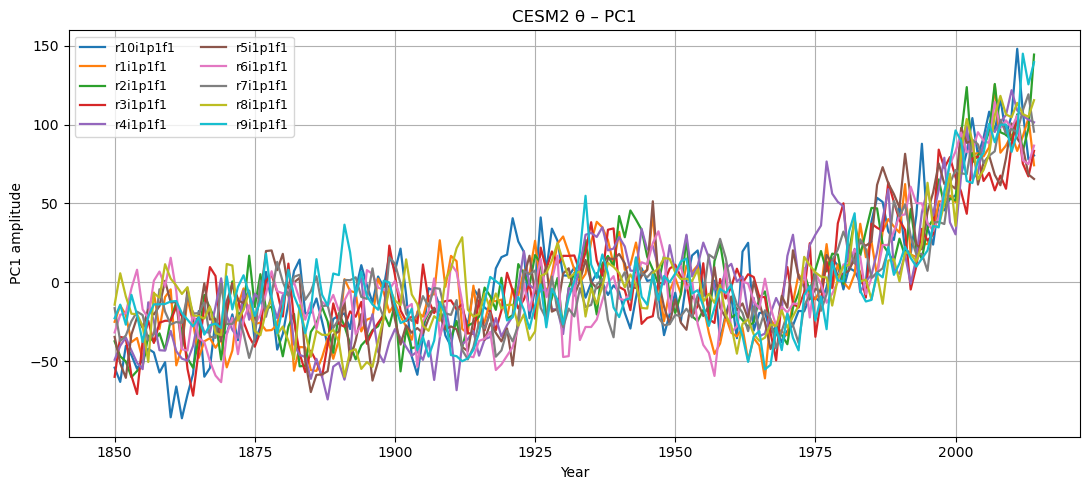

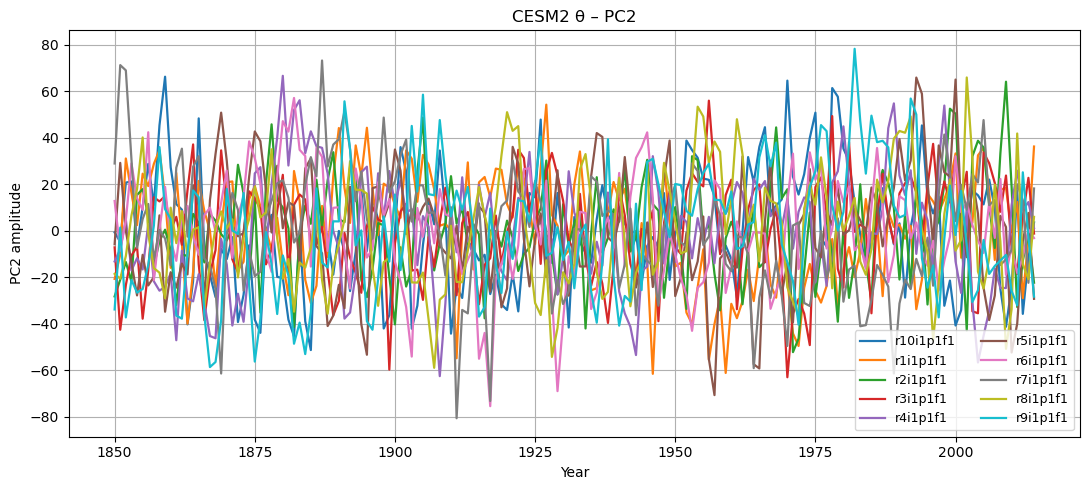

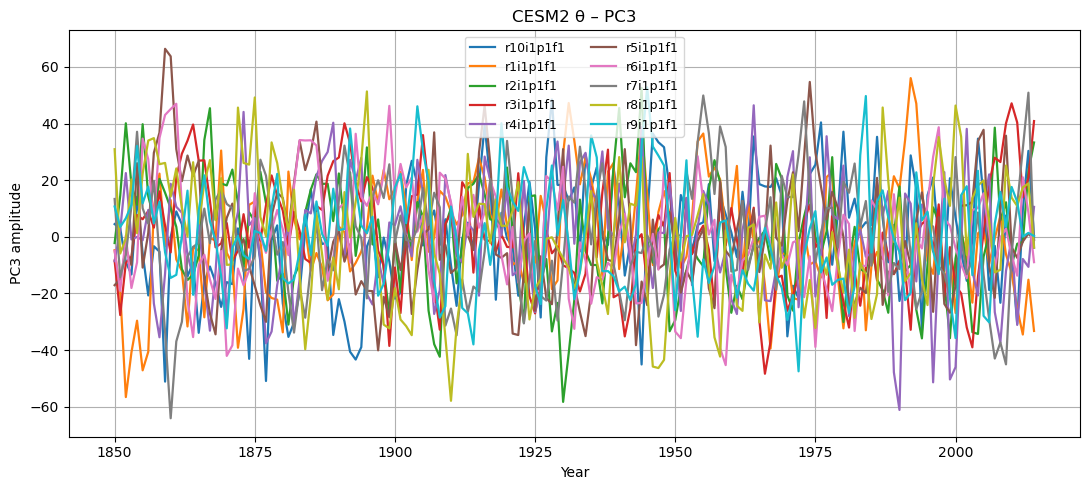


🎉 PC1, PC2, PC3 plots complete!


In [19]:
#!/usr/bin/env python3
# ============================================================
# Plot PC1, PC2, PC3 for ALL CESM2 thetao ensemble members
# ============================================================

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

# ----------------------------
# Paths
# ----------------------------
indir = "/data/projects/nckf/frekle/EOF_results/CESM2/thetao/"

# Load all EOF result files
files = sorted(glob(f"{indir}/EOF_thetao_r*i1p1f1.nc"))
print("Found files:", len(files))
for f in files:
    print(" →", f)

# Color cycle (so each member has unique color)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

# ==========================================
# Helper to plot PC(k)
# ==========================================
def plot_PC(k):
    plt.figure(figsize=(11, 5))
    plt.title(f"CESM2 θ – PC{k}")
    plt.grid(True)

    for i, f in enumerate(files):
        ds = xr.open_dataset(f)

        pcs = ds["PC"].values     # (time, mode)
        time_len = pcs.shape[0]

        # --- Make real year axis ---
        years = 1850 + np.arange(time_len)

        pc = pcs[:, k-1]  # PC1/PC2/PC3

        plt.plot(years, pc, lw=1.6, color=colors[i],
                 label=f"{f.split('_')[-1].split('.')[0]}")

    plt.xlabel("Year")
    plt.ylabel(f"PC{k} amplitude")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()



# ==========================================
# Make the 3 required plots
# ==========================================

plot_PC(1)
plot_PC(2)
plot_PC(3)

print("\n🎉 PC1, PC2, PC3 plots complete!")


Found files: 10
Combined EOF shape: (10, 10, 384, 320)


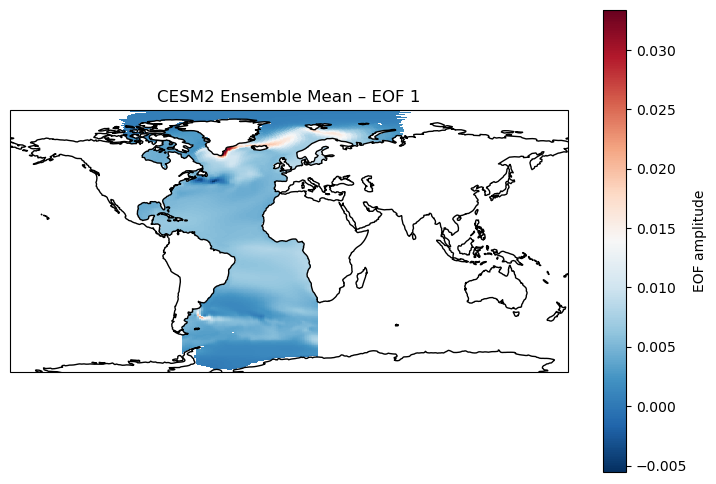

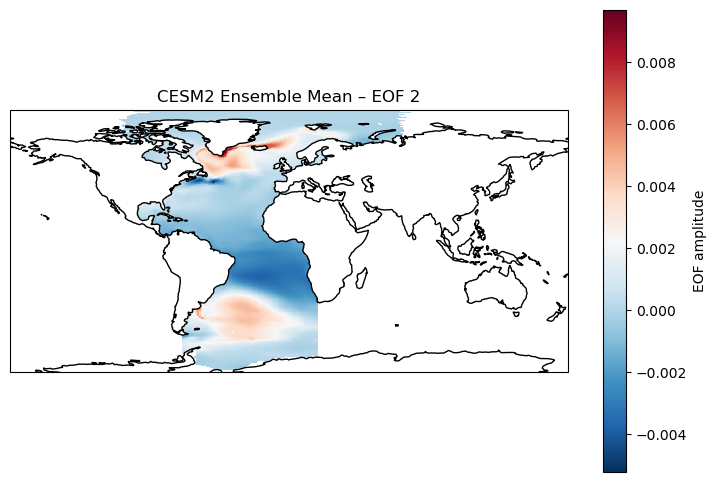

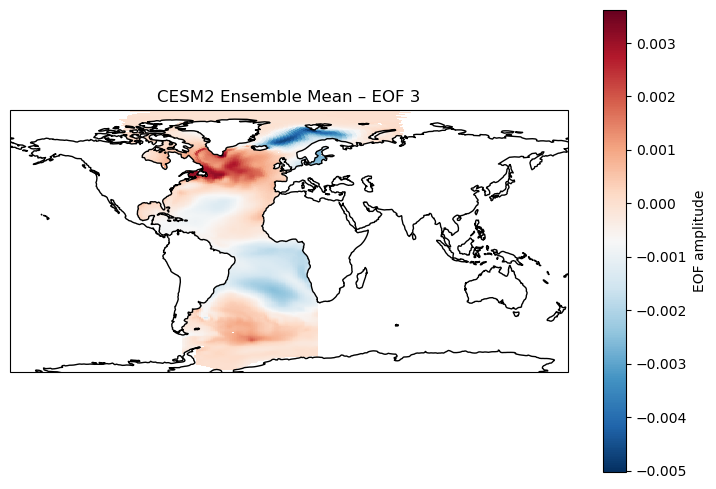

Done! Ensemble mean EOF1–3 successfully plotted.


In [22]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import cartopy.crs as ccrs

# ----------------------------
# Paths
# ----------------------------
eof_dir = "/data/projects/nckf/frekle/EOF_results/CESM2/thetao/"
files = sorted(glob(f"{eof_dir}/EOF_thetao_*.nc"))

print("Found files:", len(files))
if len(files) == 0:
    raise RuntimeError("No EOF files found!")

# ----------------------------
# Load first file → get grid
# ----------------------------
ds0 = xr.open_dataset(files[0])
lat = ds0["lat"].values       # (nlat, nlon)
lon = ds0["lon"].values       # (nlat, nlon)

# ----------------------------
# Load all EOF maps (mode, nlat, nlon)
# ----------------------------
eof_list = []

for f in files:
    ds = xr.open_dataset(f)
    eof_list.append(ds["EOF"])     # dims: (mode, nlat, nlon)

# Stack into one array (member, mode, nlat, nlon)
eofs = xr.concat(eof_list, dim="member")
print("Combined EOF shape:", eofs.shape)

# ----------------------------
# Compute ensemble mean EOF1–3
# ----------------------------
EOF1 = eofs.isel(mode=0).mean(dim="member")     # (nlat, nlon)
EOF2 = eofs.isel(mode=1).mean(dim="member")
EOF3 = eofs.isel(mode=2).mean(dim="member")

# ----------------------------
# Helper function to plot like your good version
# ----------------------------
def plot_eof(eof_map, mode_number):
    plt.figure(figsize=(9, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()

    pc = plt.pcolormesh(
        lon, lat, eof_map,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        shading="nearest"
    )

    plt.colorbar(pc, label="EOF amplitude")
    plt.title(f"CESM2 Ensemble Mean – EOF {mode_number}")
    plt.show()


# ----------------------------
# MAKE THE PLOTS
# ----------------------------
plot_eof(EOF1, 1)
plot_eof(EOF2, 2)
plot_eof(EOF3, 3)

print("Done! Ensemble mean EOF1–3 successfully plotted.")


### Make alignment

In [23]:
#!/usr/bin/env python3
"""
CESM2 – EOF alignment (mode matching + sign correction)
Freja Klejnstrup · DMI/AU · 2025
"""

import xarray as xr
import numpy as np
import os

# ================================
# CONFIGURATION
# ================================
MODEL = "CESM2"
VAR   = "thetao"
TOP_MODES = 3                  # align EOF1, EOF2, EOF3
REF_MEMBER = "r1i1p1f1"        # reference member
BASE_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/{VAR}/"

IN_DIR  = BASE_DIR
OUT_DIR = f"{BASE_DIR}/aligned/"
os.makedirs(OUT_DIR, exist_ok=True)

# ================================
# Helper: spatial correlation
# ================================
def spatial_correlation(a, b):
    """Pearson r for two 2D patterns."""
    a_, b_ = xr.align(a, b, join="inner")
    av, bv = a_.values, b_.values
    mask = np.isfinite(av) & np.isfinite(bv)
    if mask.sum() < 5:
        return np.nan
    av = av[mask]
    bv = bv[mask]
    av -= av.mean()
    bv -= bv.mean()
    return float(np.dot(av, bv) / np.sqrt(np.sum(av**2) * np.sum(bv**2)))

# ================================
# Helper: mode mapping + sign fix
# ================================
def map_and_sign_align(ref_eofs, mem_eofs, topmodes=3, lock_first=True):
    """
    Match each member's EOF modes to the reference:
    - Highest spatial correlation wins.
    - Sign is corrected so corr > 0.
    - EOF1 is locked (never swapped).
    """
    corr_mat = np.full((topmodes, topmodes), np.nan)

    # Compute correlation matrix
    for i in range(topmodes):
        for j in range(topmodes):
            corr_mat[i, j] = spatial_correlation(
                ref_eofs.isel(mode=i), mem_eofs.isel(mode=j)
            )

    mapping = {}
    used = set()

    # --- Lock EOF1 ---
    if lock_first:
        mapping[0] = 0
        used.add(0)
    else:
        best_j = int(np.nanargmax(corr_mat[0, :]))
        mapping[0] = best_j
        used.add(best_j)

    # --- Match remaining modes ---
    for i in range(1, topmodes):
        ranks = np.argsort(-corr_mat[i, :])
        for j in ranks:
            if j not in used and np.isfinite(corr_mat[i, j]):
                mapping[i] = int(j)
                used.add(j)
                break

    # --- Apply mapping + sign correction ---
    aligned_list = []
    sign_dict = {}

    for i in range(topmodes):
        j = mapping[i]
        pattern = mem_eofs.isel(mode=j)
        sign = np.sign(corr_mat[i, j])
        if sign == 0 or np.isnan(sign):
            sign = 1
        pattern = pattern * sign
        sign_dict[j] = sign
        aligned_list.append(pattern)

    out = xr.concat(aligned_list, dim="mode")
    out = out.assign_coords(mode=np.arange(1, topmodes + 1))

    return out, mapping, sign_dict


# ================================
# Helper: reorder + sign-correct PCs
# ================================
def reorder_and_flip_pcs(pcs, mapping, sign_dict, topmodes=3):
    pcs_out = []
    for i in range(topmodes):
        j = mapping[i]
        pc = pcs.isel(mode=j) * sign_dict[j]
        pcs_out.append(pc)
    pcs_out = xr.concat(pcs_out, dim="mode").transpose("time", "mode")
    pcs_out = pcs_out.assign_coords(mode=np.arange(1, topmodes + 1))
    return pcs_out

# ================================================================
# MAIN
# ================================================================
# Load reference member
ref_file = f"{IN_DIR}/EOF_thetao_{REF_MEMBER}.nc"
print(f"\n📌 Using reference: {ref_file}")

ref_ds = xr.open_dataset(ref_file)
ref_eofs = ref_ds["EOF"].isel(mode=slice(0, TOP_MODES))

# Loop over all members
for fname in sorted(os.listdir(IN_DIR)):
    if not fname.startswith("EOF_thetao_") or not fname.endswith(".nc"):
        continue

    member = fname.split("EOF_thetao_")[1].split(".nc")[0]

    in_path = f"{IN_DIR}/{fname}"
    out_path = f"{OUT_DIR}/EOF_thetao_{member}_aligned.nc"

    print(f"\n🔍 Processing {member} ...")
    ds = xr.open_dataset(in_path)

    eofs = ds["EOF"]
    pcs  = ds["PC"]
    vf   = ds["variance_fraction"]

    # Skip reference → copy directly
    if member == REF_MEMBER:
        print("   → Reference member: copying unchanged.")
        ds.to_netcdf(out_path)
        continue

    # --- alignment ---
    eofs_aligned, mapping, sign_dict = map_and_sign_align(ref_eofs, eofs, TOP_MODES)
    pcs_aligned = reorder_and_flip_pcs(pcs, mapping, sign_dict)

    # reorder variance too
    vf_sel = xr.concat([vf.isel(mode=mapping[i]) for i in range(TOP_MODES)], dim="mode")
    vf_sel = vf_sel.assign_coords(mode=np.arange(1, TOP_MODES + 1))

    # --- save ---
    aligned_ds = xr.Dataset({
        "EOF": eofs_aligned,
        "PC": pcs_aligned,
        "variance_fraction": vf_sel,
        "lat": ds["lat"],
        "lon": ds["lon"],
        "time": ds["time"]
    })

    aligned_ds.to_netcdf(out_path)
    print(f"   ✅ Saved aligned: {out_path}")

print("\n🎉 ALL MEMBERS ALIGNED SUCCESSFULLY!")



📌 Using reference: /data/projects/nckf/frekle/EOF_results/CESM2/thetao//EOF_thetao_r1i1p1f1.nc

🔍 Processing r10i1p1f1 ...
   ✅ Saved aligned: /data/projects/nckf/frekle/EOF_results/CESM2/thetao//aligned//EOF_thetao_r10i1p1f1_aligned.nc

🔍 Processing r1i1p1f1 ...
   → Reference member: copying unchanged.

🔍 Processing r2i1p1f1 ...
   ✅ Saved aligned: /data/projects/nckf/frekle/EOF_results/CESM2/thetao//aligned//EOF_thetao_r2i1p1f1_aligned.nc

🔍 Processing r3i1p1f1 ...
   ✅ Saved aligned: /data/projects/nckf/frekle/EOF_results/CESM2/thetao//aligned//EOF_thetao_r3i1p1f1_aligned.nc

🔍 Processing r4i1p1f1 ...
   ✅ Saved aligned: /data/projects/nckf/frekle/EOF_results/CESM2/thetao//aligned//EOF_thetao_r4i1p1f1_aligned.nc

🔍 Processing r5i1p1f1 ...
   ✅ Saved aligned: /data/projects/nckf/frekle/EOF_results/CESM2/thetao//aligned//EOF_thetao_r5i1p1f1_aligned.nc

🔍 Processing r6i1p1f1 ...
   ✅ Saved aligned: /data/projects/nckf/frekle/EOF_results/CESM2/thetao//aligned//EOF_thetao_r6i1p1f1_alig

In [28]:
#!/usr/bin/env python3
"""
Print alignment summary for all CESM2 members.
Reads the aligned + raw files and recomputes mapping/sign info.
"""

import xarray as xr
import numpy as np
import os

MODEL = "CESM2"
VAR   = "thetao"
TOP_MODES = 3
REF_MEMBER = "r1i1p1f1"

BASE_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/{VAR}/"
IN_DIR   = BASE_DIR                     # raw folder
OUT_DIR  = f"{BASE_DIR}/aligned/"       # aligned folder

# --- Must reuse the exact same alignment helpers ---
def spatial_correlation(a, b):
    a_, b_ = xr.align(a, b, join="inner")
    av, bv = a_.values, b_.values
    mask = np.isfinite(av) & np.isfinite(bv)
    if mask.sum() < 5:
        return np.nan
    av = av[mask] - np.mean(av[mask])
    bv = bv[mask] - np.mean(bv[mask])
    return float(np.dot(av, bv) / np.sqrt(np.sum(av**2) * np.sum(bv**2)))

def map_and_sign_align(ref_eofs, mem_eofs, topmodes=3):
    corr_mat = np.full((topmodes, topmodes), np.nan)
    for i in range(topmodes):
        for j in range(topmodes):
            corr_mat[i,j] = spatial_correlation(ref_eofs.isel(mode=i),
                                                mem_eofs.isel(mode=j))

    mapping = {}
    used = set()
    mapping[0] = 0
    used.add(0)

    for i in range(1, topmodes):
        ranked = np.argsort(-corr_mat[i,:])
        for j in ranked:
            if j not in used and np.isfinite(corr_mat[i,j]):
                mapping[i] = int(j)
                used.add(j)
                break

    # sign corrections
    sign_dict = {}
    for i in range(topmodes):
        j = mapping[i]
        s = np.sign(corr_mat[i,j])
        if s == 0 or np.isnan(s):
            s = 1
        sign_dict[j] = s

    return mapping, sign_dict


# =====================================================
# Load reference
# =====================================================
ref_file = f"{IN_DIR}/EOF_{VAR}_{REF_MEMBER}.nc"
ref_ds = xr.open_dataset(ref_file)
ref_eofs = ref_ds["EOF"].isel(mode=slice(0, TOP_MODES))


print("\n==============================")
print("🔎 ALIGNMENT SUMMARY (ALL MEMBERS)")
print("==============================\n")

# Loop through both raw + aligned files
for fname in sorted(os.listdir(IN_DIR)):
    if not fname.startswith("EOF_thetao_") or not fname.endswith(".nc"):
        continue

    member = fname.split("EOF_thetao_")[1].split(".nc")[0]
    if member == REF_MEMBER:
        continue

    # load raw + aligned EOFs
    raw_ds = xr.open_dataset(f"{IN_DIR}/{fname}")
    aligned_ds = xr.open_dataset(f"{OUT_DIR}/EOF_thetao_{member}_aligned.nc")

    raw_eofs = raw_ds["EOF"].isel(mode=slice(0, TOP_MODES))
    aligned_eofs = aligned_ds["EOF"]

    # recompute mapping
    mapping, sign_dict = map_and_sign_align(ref_eofs, raw_eofs, TOP_MODES)

    print(f"\n📌 Member: {member}")

    # --- Swaps ---
    swapped = False
    for i in range(TOP_MODES):
        j = mapping[i]
        if j != i:
            print(f"  ↪ Swapped: EOF{i+1}  ←  raw EOF{j+1}")
            swapped = True

    if not swapped:
        print("  ✔ No swaps")

    # --- Sign flips ---
    flipped = False
    for j, s in sign_dict.items():
        if s == -1:
            print(f"  ↪ Sign flip: EOF{j+1} (× -1)")
            flipped = True

    if not flipped:
        print("  ✔ No sign flips")

    # --- Variance reorder ---
    variance = raw_ds["variance_fraction"]
    reordered = False
    for i in range(TOP_MODES):
        j = mapping[i]
        if j != i:
            print(f"  ↪ Variance: mode {i+1} takes variance from raw mode {j+1}")
            reordered = True

    if not reordered:
        print("  ✔ Variance unchanged")

print("\n🎉 Finished printing alignment summary for all members!")



🔎 ALIGNMENT SUMMARY (ALL MEMBERS)


📌 Member: r10i1p1f1
  ↪ Swapped: EOF2  ←  raw EOF3
  ↪ Swapped: EOF3  ←  raw EOF2
  ✔ No sign flips
  ↪ Variance: mode 2 takes variance from raw mode 3
  ↪ Variance: mode 3 takes variance from raw mode 2

📌 Member: r2i1p1f1
  ✔ No swaps
  ↪ Sign flip: EOF3 (× -1)
  ✔ Variance unchanged

📌 Member: r3i1p1f1
  ✔ No swaps
  ↪ Sign flip: EOF3 (× -1)
  ✔ Variance unchanged

📌 Member: r4i1p1f1
  ✔ No swaps
  ↪ Sign flip: EOF2 (× -1)
  ↪ Sign flip: EOF3 (× -1)
  ✔ Variance unchanged

📌 Member: r5i1p1f1
  ✔ No swaps
  ✔ No sign flips
  ✔ Variance unchanged

📌 Member: r6i1p1f1
  ✔ No swaps
  ✔ No sign flips
  ✔ Variance unchanged

📌 Member: r7i1p1f1
  ✔ No swaps
  ↪ Sign flip: EOF3 (× -1)
  ✔ Variance unchanged

📌 Member: r8i1p1f1
  ↪ Swapped: EOF2  ←  raw EOF3
  ↪ Swapped: EOF3  ←  raw EOF2
  ✔ No sign flips
  ↪ Variance: mode 2 takes variance from raw mode 3
  ↪ Variance: mode 3 takes variance from raw mode 2

📌 Member: r9i1p1f1
  ↪ Swapped: EOF2  ←  raw EO


Searching: /data/projects/nckf/frekle/EOF_results/CESM2/thetao/EOF_thetao_r*i1p1f1.nc
Found 10 files

Searching: /data/projects/nckf/frekle/EOF_results/CESM2/thetao/aligned/EOF_thetao_r*i1p1f1_aligned.nc
Found 10 files

Common members: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Years array: [1850.49611872 1851.49611872 1852.49611872 1853.49611872 1854.49611872] ...


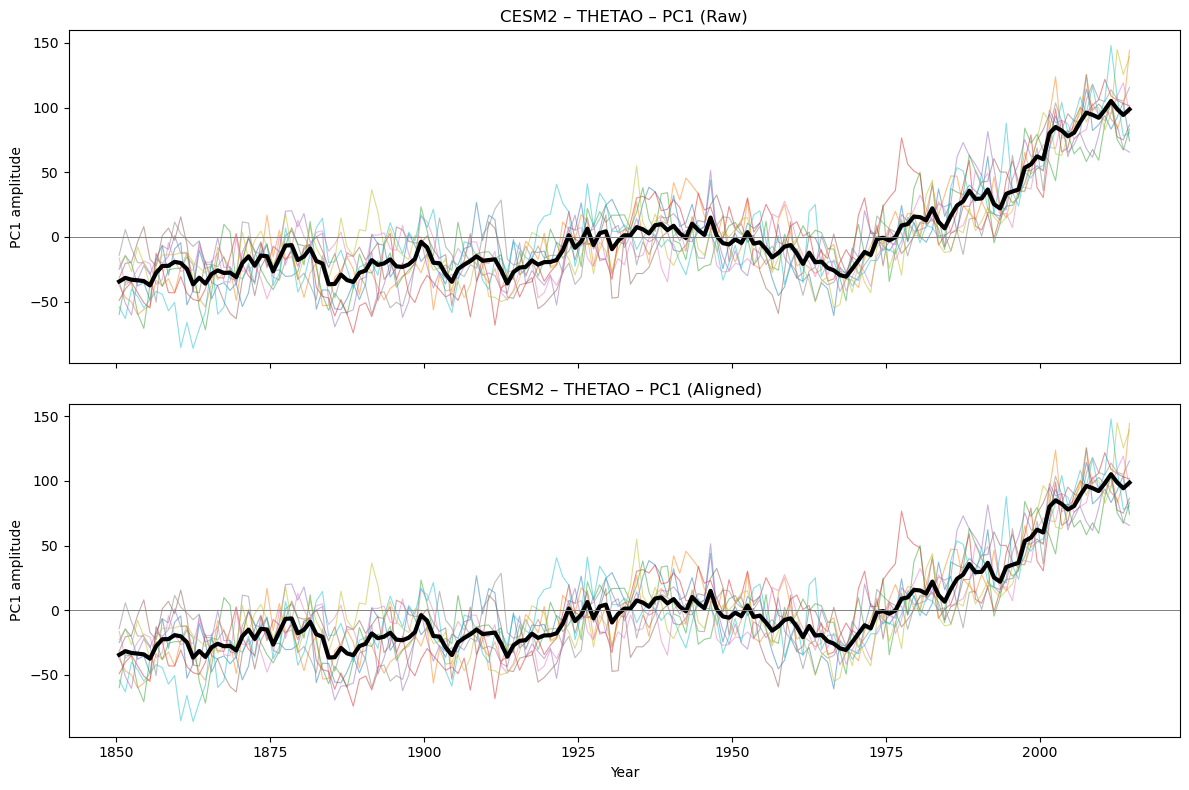


✅ Saved figure: /data/users/frekle/EOF/CESM2/Figures/thetao_PC1_alignment.png


In [27]:
import xarray as xr
import matplotlib.pyplot as plt
import glob
import numpy as np
import os
import re

# ========================================
# MODEL SETTINGS
# ========================================
MODEL = "CESM2"
VAR   = "thetao"

RAW_DIR     = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/{VAR}"
ALIGNED_DIR = f"{RAW_DIR}/aligned"

OUT_FIG = f"/data/users/frekle/EOF/{MODEL}/Figures/{VAR}_PC1_alignment.png"
os.makedirs(os.path.dirname(OUT_FIG), exist_ok=True)


# ========================================
# Helper: load all PC1s in a folder
# ========================================
def load_pc1_dict(folder, aligned=False):
    pcs_dict = {}

    if aligned:
        pattern = os.path.join(folder, f"EOF_{VAR}_r*i1p1f1_aligned.nc")
    else:
        pattern = os.path.join(folder, f"EOF_{VAR}_r*i1p1f1.nc")  # raw files

    files = sorted(glob.glob(pattern))
    print(f"\nSearching: {pattern}")
    print(f"Found {len(files)} files")

    for f in files:
        fname = os.path.basename(f)

        m = re.search(r"_r(\d+)i1p1f1", fname)
        if not m:
            print(f"⚠️ Could not read member number from: {fname}")
            continue

        member = int(m.group(1))

        try:
            ds = xr.open_dataset(f)

            # variable names differ from IPSL script: CESM2 uses "PC"
            pc1 = ds["PC"].isel(mode=0).load()
            pcs_dict[member] = pc1

        except Exception as e:
            print(f"⚠️ Error loading {fname}: {e}")

    return pcs_dict


# ========================================
# Load raw and aligned PC1
# ========================================
pcs_raw     = load_pc1_dict(RAW_DIR, aligned=False)
pcs_aligned = load_pc1_dict(ALIGNED_DIR, aligned=True)

# intersection of members
common_members = sorted(set(pcs_raw.keys()) & set(pcs_aligned.keys()))
print(f"\nCommon members: {common_members}")

pcs_raw     = {m: pcs_raw[m] for m in common_members}
pcs_aligned = {m: pcs_aligned[m] for m in common_members}

# stack into xarray arrays
time = list(pcs_raw.values())[0]["time"].values

# ========================================
# Convert CESM cftime → numeric years
# ========================================
def cftime_to_years(time_array):
    years = []
    for t in time_array:
        y = t.year + (t.month - 1)/12 + (t.day - 1)/365
        years.append(y)
    return np.array(years)

years = cftime_to_years(time)
print("Years array:", years[:5], "...")

raw_stack     = xr.concat([pcs_raw[m] for m in common_members], dim="member")
aligned_stack = xr.concat([pcs_aligned[m] for m in common_members], dim="member")

raw_mean     = raw_stack.mean("member")
aligned_mean = aligned_stack.mean("member")


# ========================================
# PLOTTING
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ---- RAW ----
ax = axes[0]
for m in common_members:
    ax.plot(years, pcs_raw[m], lw=0.8, alpha=0.5)
ax.plot(years, raw_mean, color="k", lw=3, label="Ensemble mean")

ax.set_ylabel("PC1 amplitude")
ax.set_title(f"{MODEL} – {VAR.upper()} – PC1 (Raw)")
ax.axhline(0, color="gray", lw=0.7)

# ---- ALIGNED ----
ax = axes[1]
for m in common_members:
    ax.plot(years, pcs_aligned[m], lw=0.8, alpha=0.5)
ax.plot(years, aligned_mean, color="k", lw=3, label="Ensemble mean")

ax.set_ylabel("PC1 amplitude")
ax.set_xlabel("Year")
ax.set_title(f"{MODEL} – {VAR.upper()} – PC1 (Aligned)")
ax.axhline(0, color="gray", lw=0.7)

plt.tight_layout()
plt.savefig(OUT_FIG, dpi=300)
plt.show()

print(f"\n✅ Saved figure: {OUT_FIG}")



Found 10 aligned members.


/tmp/ipykernel_3041465/1488292159.py:42: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'mode' ('mode',) The recommendation is to set join explicitly for this case.
  pc_stack = xr.concat([pcs_dict[m] for m in members], dim="member")


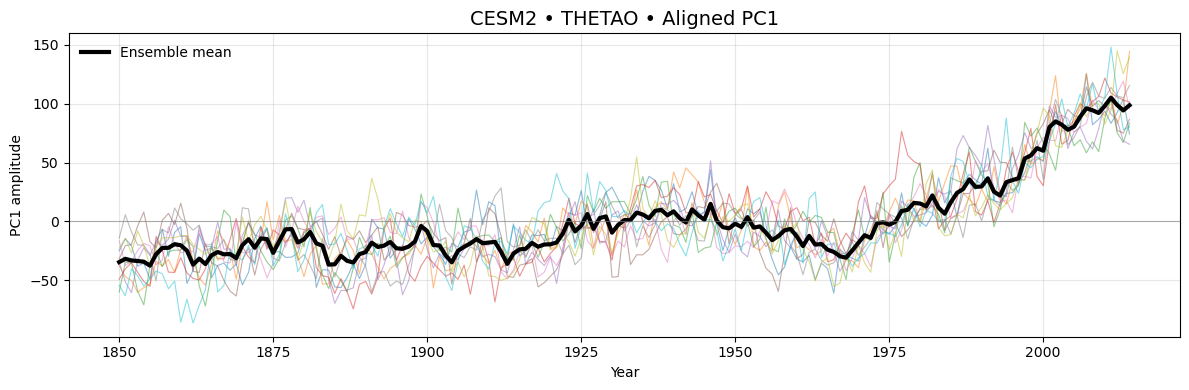

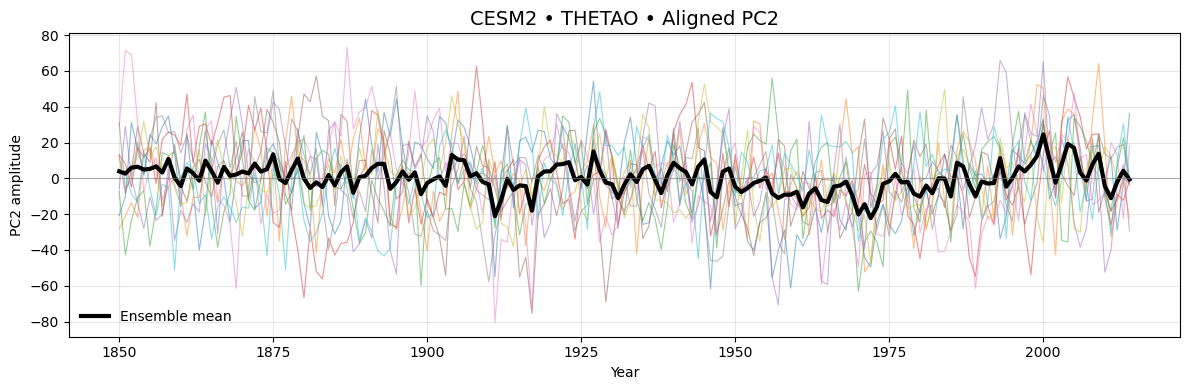

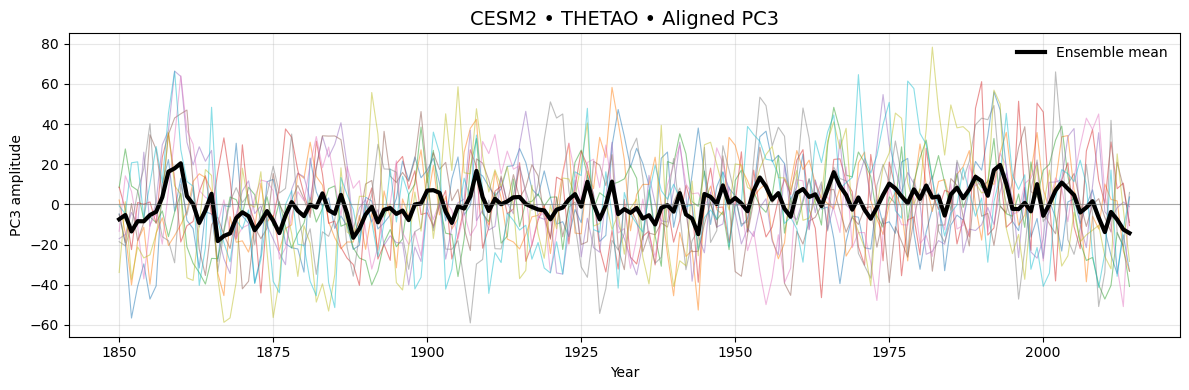

In [29]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import re

MODEL = "CESM2"
VAR   = "thetao"
TOP_MODES = 3

ALIGNED_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/{VAR}/aligned/"

# ------------------------------------------------------------
# Load aligned PCs
# ------------------------------------------------------------
pcs_dict = {}
pattern = os.path.join(ALIGNED_DIR, f"EOF_{VAR}_r*i1p1f1_aligned.nc")
files = sorted(glob.glob(pattern))

print(f"Found {len(files)} aligned members.")

for f in files:
    fname = os.path.basename(f)
    match = re.search(r"_r(\d+)i1p1f1_", fname)
    if not match:
        continue
    mem = int(match.group(1))

    ds = xr.open_dataset(f)
    pcs = ds["PC"]     # dims: time × mode
    pcs_dict[mem] = pcs

# ----------------------------------------------------------------
# Ensure all members have the same time coordinate
# ----------------------------------------------------------------
members = sorted(pcs_dict.keys())
time = pcs_dict[members[0]]["time"]
years = time.dt.year

# Stack into arrays for easier mean computation
pc_stack = xr.concat([pcs_dict[m] for m in members], dim="member")

# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------
def plot_PC(mode):
    """
    Plot one PC across all members + ensemble mean.
    mode = 1,2,3
    """
    idx = mode - 1

    plt.figure(figsize=(12, 4))
    for m in members:
        plt.plot(years, pcs_dict[m].isel(mode=idx), lw=0.8, alpha=0.5)

    mean_pc = pc_stack.isel(mode=idx).mean("member")
    plt.plot(years, mean_pc, color="k", lw=3, label="Ensemble mean")

    plt.axhline(0, color="gray", lw=0.8, alpha=0.6)
    plt.title(f"{MODEL} • {VAR.upper()} • Aligned PC{mode}", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel(f"PC{mode} amplitude")
    plt.grid(alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Make the three plots
# ------------------------------------------------------------
plot_PC(1)
plot_PC(2)
plot_PC(3)


📌 Loaded 10 members: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


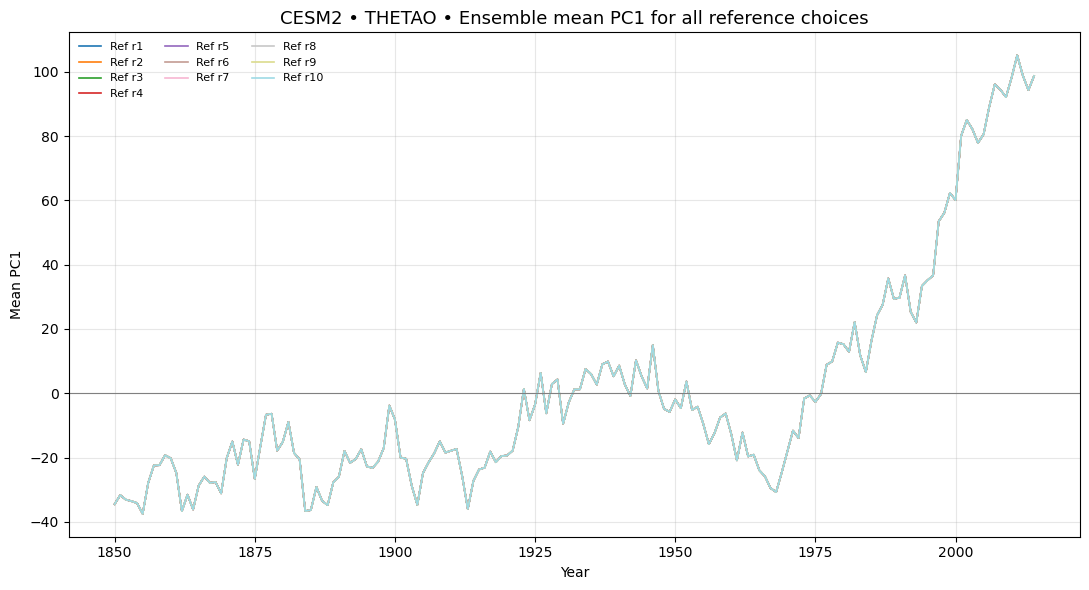

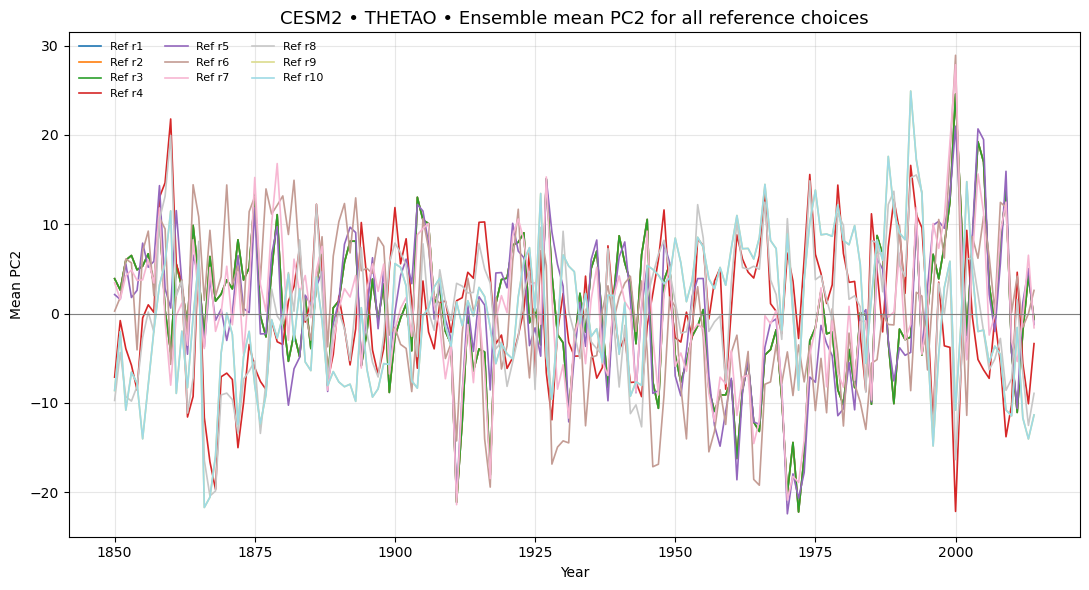

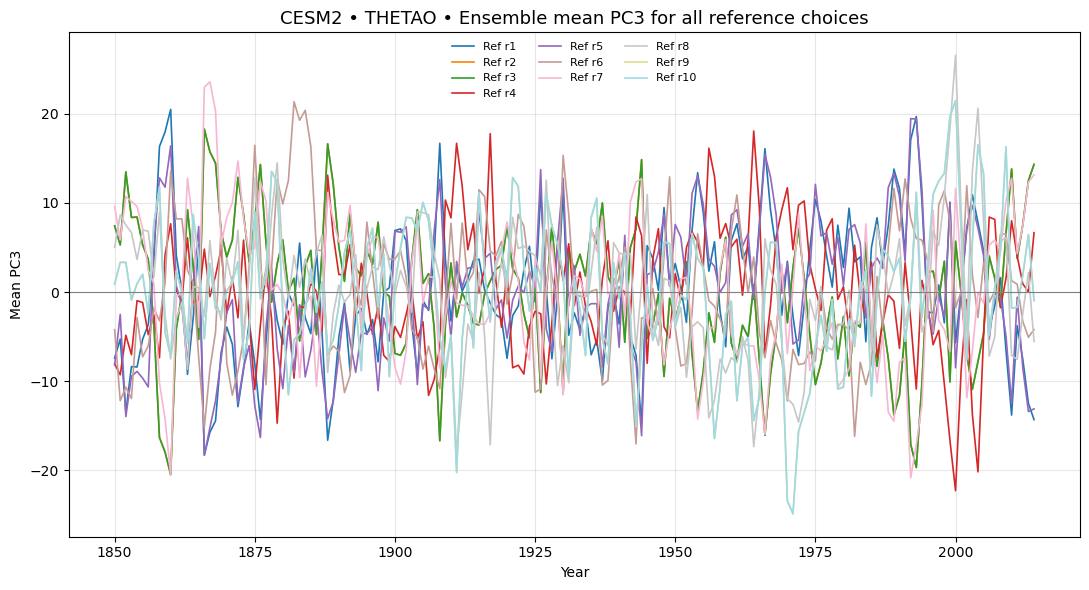

In [30]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import re
import os

# =====================================================
# CONFIG
# =====================================================
MODEL = "CESM2"
VAR = "thetao"
TOP_MODES = 3     # EOF1,2,3

IN_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/{VAR}/"

# =====================================================
# FUNCTIONS
# =====================================================
def spatial_correlation(a, b):
    a_, b_ = xr.align(a, b, join="inner")
    av, bv = a_.values, b_.values
    mask = np.isfinite(av) & np.isfinite(bv)
    if mask.sum() < 3:
        return np.nan
    av = av[mask] - av[mask].mean()
    bv = bv[mask] - bv[mask].mean()
    return float(np.dot(av, bv) / np.sqrt(np.sum(av**2) * np.sum(bv**2)))


def map_and_sign_align(ref_eofs, mem_eofs, topmodes=TOP_MODES):
    """Align EOFs of one member to reference EOFs by correlation & sign."""
    
    corr_mat = np.full((topmodes, topmodes), np.nan)
    for i in range(topmodes):
        for j in range(topmodes):
            corr_mat[i, j] = spatial_correlation(
                ref_eofs.isel(mode=i), mem_eofs.isel(mode=j)
            )

    mapping = {}
    used = set()

    for i in range(topmodes):
        ranked = np.argsort(-corr_mat[i])
        for j in ranked:
            if j not in used:
                mapping[i] = int(j)
                used.add(j)
                break

    # Apply swaps + sign
    aligned = []
    sign_dict = {}

    for i in range(topmodes):
        j = mapping[i]
        pattern = mem_eofs.isel(mode=j)
        sign = 1 if corr_mat[i, j] >= 0 else -1
        sign_dict[j] = sign
        aligned.append(pattern * sign)

    out = xr.concat(aligned, dim="mode").assign_coords(mode=np.arange(1, topmodes+1))
    return out, mapping, sign_dict


def reorder_and_flip_pcs(pcs, mapping, sign_dict, topmodes=TOP_MODES):
    pcs_out = []
    for i in range(topmodes):
        j = mapping[i]
        pcs_out.append(pcs.isel(mode=j) * sign_dict[j])

    pcs_out = xr.concat(pcs_out, dim="mode").transpose("time", "mode")
    return pcs_out.assign_coords(mode=np.arange(1, topmodes+1))


# =====================================================
# LOAD RAW EOF/PC DATA
# =====================================================
raw_files = sorted(glob.glob(os.path.join(IN_DIR, "EOF_thetao_r*i1p1f1.nc")))

members = []
eofs_all, pcs_all = {}, {}

for f in raw_files:
    fname = os.path.basename(f)
    m = re.search(r"_r(\d+)i1p1f1", fname)
    if not m:
        continue
    member = int(m.group(1))

    ds = xr.open_dataset(f)
    eofs_all[member] = ds["EOF"].isel(mode=slice(0, TOP_MODES))
    pcs_all[member] = ds["PC"].isel(mode=slice(0, TOP_MODES))
    members.append(member)

members = sorted(members)
print(f"📌 Loaded {len(members)} members:", members)

# Shared time axis
time = pcs_all[members[0]].time
years = time.dt.year

colors = plt.cm.tab20(np.linspace(0,1,len(members)))

# =====================================================
# MAKE PLOTS FOR PC1, PC2, PC3
# =====================================================
def plot_mean_PC_for_all_references(pc_mode):

    plt.figure(figsize=(11,6))
    for idx, ref in enumerate(members):

        ref_eofs = eofs_all[ref]
        aligned_list = []

        for mem in members:

            if mem == ref:
                # reference member is identity
                pcs_aligned = pcs_all[mem].isel(mode=pc_mode)
            else:
                eofs_mem = eofs_all[mem]
                pcs_mem  = pcs_all[mem]

                eofs_aligned, mapping, sign_dict = map_and_sign_align(ref_eofs, eofs_mem)
                pcs_aligned = reorder_and_flip_pcs(pcs_mem, mapping, sign_dict).isel(mode=pc_mode)

            aligned_list.append(pcs_aligned)

        stack = xr.concat(aligned_list, dim="member")
        mean_pc = stack.mean("member")

        plt.plot(years, mean_pc, color=colors[idx], lw=1.2, label=f"Ref r{ref}")

    plt.axhline(0, color="gray", lw=0.8)
    plt.title(f"{MODEL} • {VAR.upper()} • Ensemble mean PC{pc_mode+1} for all reference choices", fontsize=13)
    plt.xlabel("Year")
    plt.ylabel(f"Mean PC{pc_mode+1}")
    plt.legend(ncol=3, fontsize=8, frameon=False)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------
# PLOT PC1, PC2, PC3
# ------------------------------------------------------
plot_mean_PC_for_all_references(0)
plot_mean_PC_for_all_references(1)
plot_mean_PC_for_all_references(2)


Loaded EC-Earth3 members: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


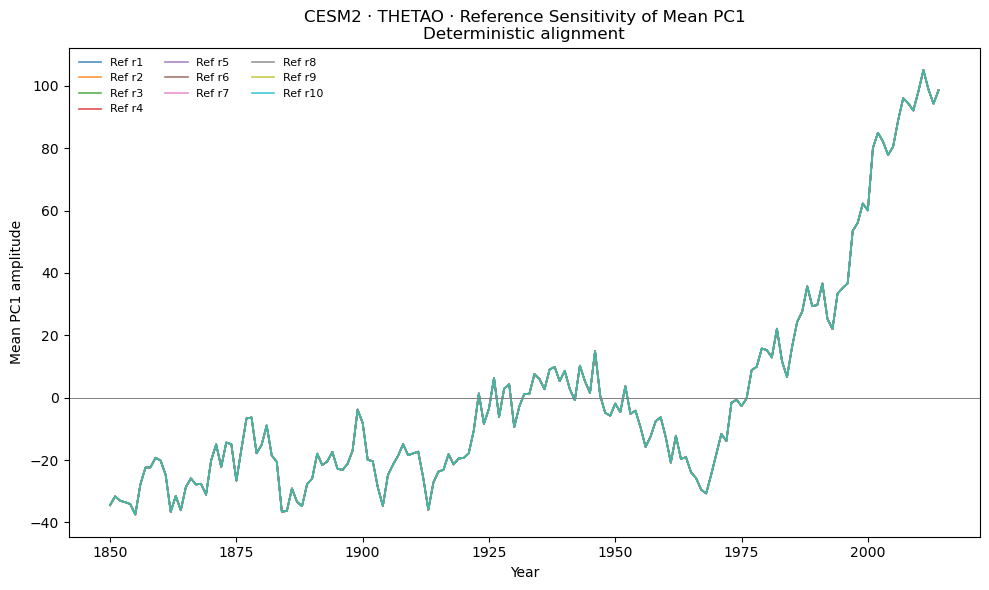

In [33]:
#!/usr/bin/env python3
# =====================================================
# EC-Earth3 — Reference Sensitivity of EOF Alignment
# Deterministic (CESM-style) alignment across references
# Freja Klejnstrup · DMI/AU · 2025
# =====================================================

import xarray as xr
import numpy as np
import glob
import re
import os
import matplotlib.pyplot as plt
import cftime

# ================================
# CONFIG
# ================================
MODEL = "CESM2"
VAR   = "thetao"

IN_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/{VAR}"

TOP_MODES = 3      # Only align EOF1-EOF3, but correlation uses ALL modes


# ================================
# Helper: spatial correlation
# ================================
def pattern_corr(eof1, eof2):
    """Compute spatial (Pearson) correlation between two 2D EOF patterns."""
    a = eof1.values.flatten()
    b = eof2.values.flatten()

    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan

    a = a[m] - a[m].mean()
    b = b[m] - b[m].mean()

    return float(np.dot(a, b) /
                 (np.sqrt((a*a).sum()) * np.sqrt((b*b).sum())))


# ================================
# Deterministic alignment
# ================================
def deterministic_align(ref_eofs, mem_eofs, topmodes=TOP_MODES):
    """
    Deterministic mode alignment:
      • Build full correlation matrix
      • For each mode i → choose j = argmax(|corr[i,j]|)
      • Apply sign so corr > 0
      • No 'used' filtering → deterministic & stable
    """

    nm = ref_eofs.sizes["mode"]
    corr_mat = np.zeros((topmodes, nm))

    # --- compute full correlation matrix ---
    for i in range(topmodes):
        for j in range(nm):
            corr_mat[i, j] = pattern_corr(ref_eofs.isel(mode=i),
                                          mem_eofs.isel(mode=j))

    # --- strict row-based matching ---
    mapping = {i: int(np.nanargmax(np.abs(corr_mat[i, :])))
               for i in range(topmodes)}

    # --- sign correction ---
    aligned = []
    for i in range(topmodes):
        j = mapping[i]
        corr = corr_mat[i, j]
        sign = 1 if corr >= 0 else -1
        aligned.append(mem_eofs.isel(mode=j) * sign)

    aligned = xr.concat(aligned, dim="mode")
    aligned = aligned.assign_coords(mode=np.arange(1, topmodes + 1))

    return aligned, mapping


# ================================
# Load all raw EOF/PC files
# ================================
files = sorted(glob.glob(os.path.join(IN_DIR,
                                      f"EOF_{VAR}_r*i1p1f1.nc")))

if not files:
    raise FileNotFoundError("No raw EOF files found!")

members = []
eofs_all = {}
pcs_all = {}

for f in files:
    fname = os.path.basename(f)
    m = re.search(r"_r(\d+)i1p1f1", fname)
    if not m:
        continue

    member = int(m.group(1))
    ds = xr.open_dataset(f)

    eofs_all[member] = ds["EOF"]     # all modes kept
    pcs_all[member]  = ds["PC"]      # all modes kept

    members.append(member)

members = sorted(members)
print(f"Loaded EC-Earth3 members: {members}")


# ================================
# Reference-sensitivity analysis
# ================================
plt.figure(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(members)))

for idx, ref in enumerate(members):

    ref_eofs = eofs_all[ref]
    aligned_pc1_list = []

    for mem in members:
        mem_eofs = eofs_all[mem]
        mem_pcs  = pcs_all[mem]

        if mem == ref:
            aligned_pc1 = mem_pcs.isel(mode=0)
        else:
            aligned_eofs, mapping = deterministic_align(ref_eofs, mem_eofs, TOP_MODES)

            j = mapping[0]  # match for EOF1
            corr = pattern_corr(ref_eofs.isel(mode=0), mem_eofs.isel(mode=j))
            sign = 1 if corr >= 0 else -1

            aligned_pc1 = mem_pcs.isel(mode=j) * sign

        aligned_pc1_list.append(aligned_pc1)

    # compute ensemble mean for this reference
    stack = xr.concat(aligned_pc1_list, dim="member")
    pc1_mean = stack.mean("member")

    # -------------------------
    # PLOT INSIDE THE LOOP!!!
    # -------------------------
    # time handling (CFTime→years safe)
    years = get_plot_years(pc1_mean["time"])

    plt.plot(years, pc1_mean,
             lw=1.2, alpha=0.8,
             color=colors[idx],
             label=f"Ref r{ref}")

plt.axhline(0, color="gray", lw=0.7)
plt.title(f"{MODEL} · {VAR.upper()} · Reference Sensitivity of Mean PC1\nDeterministic alignment")
plt.xlabel("Year")
plt.ylabel("Mean PC1 amplitude")
plt.legend(ncol=3, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()



### New EOF analysis

In [1]:
#!/usr/bin/env python3
# ============================================================
# CESM2 EOF analysis for thetao
# Done in the SAME way as IPSL script:
#  - anomalies
#  - sqrt(cos(lat)) area weights
#  - stacked (time, space)
#  - eofsAsCorrelation
#  - outputs: eofs_corr, pcs, variance_fraction
# ============================================================

import os
import numpy as np
import xarray as xr
from glob import glob
from eofs.standard import Eof as EofStd

# -------------------- SETTINGS --------------------
model = "EC-Earth3"
var   = "thetao"

indir  = f"/data/projects/nckf/frekle/CMIP6_data/{model}/"
outdir = f"/data/projects/nckf/frekle/EOF_results/{model}/{var}/"
figdir = f"/data/users/frekle/EOF/{model}/Figures/"
os.makedirs(outdir, exist_ok=True)
os.makedirs(figdir, exist_ok=True)

n_modes_total = 10

# -------------------- FUNCTIONS --------------------
def normalize_longitudes_if_1d(ds):
    """
    Convert lon 0–360 → -180–180 and sort, but ONLY if lon is 1D.
    For curvilinear (2D) lon we leave it as-is.
    """
    if "lon" in ds.coords and ds["lon"].ndim == 1:
        lon = ds["lon"]
        lon = ((lon + 180) % 360) - 180
        ds = ds.assign_coords(lon=lon).sortby("lon")
    return ds


def run_eof_numpy(anom_stacked, w_stacked):
    """Run weighted EOF and return correlation EOFs, PCs, and variance fraction."""
    solver = EofStd(anom_stacked.values, weights=w_stacked.values)

    eofs_np = solver.eofsAsCorrelation(neofs=n_modes_total)      # (mode, space)
    pcs_np  = solver.pcs(npcs=n_modes_total, pcscaling=1)        # (time, mode)
    vf_np   = solver.varianceFraction()[:n_modes_total]          # (mode,)

    eofs = xr.DataArray(
        eofs_np,
        dims=("mode", "space"),
        coords={"mode": np.arange(1, n_modes_total + 1),
                "space": anom_stacked.space},
        name="eofs_corr",
    )
    pcs = xr.DataArray(
        pcs_np,
        dims=("time", "mode"),
        coords={"time": anom_stacked.time,
                "mode": np.arange(1, n_modes_total + 1)},
        name="pcs",
    )
    vf = xr.DataArray(
        vf_np,
        dims=("mode",),
        coords={"mode": np.arange(1, n_modes_total + 1)},
        name="variance_fraction",
    )
    return eofs, pcs, vf


def main():
    # find all masked thetao files
    files = sorted(glob(os.path.join(indir, "thetao_masked_r*i1p1f1*.nc")))
    print("Found CESM2 thetao files:", len(files))
    for f in files:
        print(" →", os.path.basename(f))

    for f in files:
        fname = os.path.basename(f)
        member = fname.split("_")[-1].split(".")[0]  # r1i1p1f1 etc.
        print(f"\n🔄 Processing {member}")

        ds = xr.open_dataset(f)
        ds = normalize_longitudes_if_1d(ds)

        da = ds[var]  # (time, lev, nlat, nlon) or (time, nlat, nlon)

        # If lev exists, take surface
        if "lev" in da.dims:
            da = da.isel(lev=0)

        # anomalies
        anom = da - da.mean(dim="time", skipna=True)

        # lat + lon (2D in your case: (nlat, nlon))
        lat = ds["lat"]
        lon = ds["lon"]

        # ----- area weights: sqrt(cos(lat)) -----
        # ensure 2D weights that match anom.isel(time=0)
        if lat.ndim == 1:
            # 1D lat → broadcast to 2D
            lat_2d, _ = xr.broadcast(lat, anom.isel(time=0))
        else:
            # already 2D (nlat, nlon)
            lat_2d = lat

        lat_radians = np.deg2rad(lat_2d)
        weights_2d = np.sqrt(np.cos(lat_radians))

        # ----- stack to (time, space) using the *dimension* names -----
        # e.g. anom.dims = ("time", "nlat", "nlon")
        space_dims = [d for d in anom.dims if d != "time"]

        anom_stacked = anom.stack(space=space_dims).dropna("space", how="all")
        w_stacked = weights_2d.stack(space=space_dims).sel(space=anom_stacked.space)

        # ----- EOF -----
        eofs, pcs, vf = run_eof_numpy(anom_stacked, w_stacked)

        # back to maps: (mode, nlat, nlon) with lat/lon as coords
        eofs_map = (
            eofs.assign_coords(space=anom_stacked.space)
                .unstack("space")
                .transpose("mode", *space_dims)
        )
        # Attach lat/lon as coords for convenience
        eofs_map = eofs_map.assign_coords(lat=lat_2d, lon=lon)

        # ----- save -----
        ds_out = xr.Dataset(
            {
                "eofs_corr": eofs_map,
                "pcs": pcs,
                "variance_fraction": vf,
            }
        )

        outfile = os.path.join(outdir, f"EOF_{var}_{member}.nc")
        ds_out.to_netcdf(outfile)
        print(f"  ✔ Saved {outfile}")

    print("\n🎯 CESM2 EOFs done with the SAME method as IPSL (now 2D-grid safe).")

# --------------------------------------------------
if __name__ == "__main__":
    main()


Found CESM2 thetao files: 0

🎯 CESM2 EOFs done with the SAME method as IPSL (now 2D-grid safe).


In [6]:
import xarray as xr

MODEL = "CESM2"
VAR   = "thetao"

ds = xr.open_dataset(f"/data/projects/nckf/frekle/CMIP6_data/CESM2/thetao/masked/thetao_masked_r1i1p1f1.nc")

print(ds["lat"].shape)
print(ds["lon"].shape)
print(ds["thetao"].shape)


(384, 320)
(384, 320)
(165, 60, 384, 320)
